In [53]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [54]:
# Paths

Data_Path = Path("Public_Libraries.csv")
CLEANED_PATH = Path("Public_Libraries_Cleaned.csv")
PLOTS_DIR = Path("data/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(Data_Path)

In [55]:
# Show some info

print("Rows, Cols:", df.shape)
df.head(10)

Rows, Cols: (5278, 27)


,Fiscal Year,Library,County,AENGLC Rank,Population of Service Area,Total Library Visits,Library Visits Per Capita Served,Total Registered Borrowers,Percent of Residents with Library Cards,Reference Questions,...,Total Collection,Collection Per Capita Served,Total Operating Income,Operating Income Per Capita,Town Tax Appropriation for Library,Tax Appropriation Per Capita Served,Library Materials Expenditures,Wages & Salaries Expenditures,Operating Expenditures,Operating Expenditures Per Capita
0,1996,Andover,Tolland,109.0,2815.0,15000.0,5.3,1313.0,0.47,499.0,...,15285.0,5.4,56300.0,20.00,52915.0,18.80,10073.0,30996.0,44290.0,15.7
1,1996,Ansonia,New Haven,158.0,17825.0,91756.0,5.1,6952.0,0.39,NaN,...,63685.0,3.6,320679.0,17.99,323503.0,18.15,45874.0,201621.0,270658.0,15.2
2,1996,Ashford-Babcock,Windham,131.0,3969.0,8665.0,2.2,1360.0,0.34,207.0,...,23818.0,6.0,111699.0,28.14,106713.0,26.89,11508.0,62295.0,82769.0,20.9
3,1996,Avon,Hartford,19.0,14143.0,162893.0,11.5,8808.0,0.62,15283.0,...,74903.0,5.3,685678.0,48.48,602831.0,42.62,92711.0,340400.0,516583.0,36.5
4,1996,Beacon Falls,New Haven,129.0,5351.0,7000.0,1.3,1379.0,0.26,400.0,...,10042.0,1.9,40806.0,7.63,39256.0,7.34,4298.0,21585.0,39165.0,7.3
5,1996,Berlin-Peck,Hartford,52.0,16792.0,NaN,NaN,8142.0,0.48,6081.0,...,92322.0,5.5,638641.0,38.03,643771.0,38.34,92877.0,320919.0,480642.0,28.6
6,1996,Bethany - Clark,New Haven,54.0,4845.0,19500.0,4.0,3100.0,0.64,696.0,...,32178.0,6.6,46497.0,9.60,36483.0,7.53,9848.0,21720.0,39231.0,8.1
7,1996,Bethel,Fairfield,74.0,17921.0,155316.0,8.7,12546.0,0.70,16796.0,...,83123.0,4.6,375789.0,20.97,371859.0,20.75,89167.0,229724.0,364548.0,20.3
8,1996,Bethlehem,Litchfield,73.0,3324.0,17478.0,5.3,1952.0,0.59,NaN,...,22966.0,6.9,62571.0,18.82,56000.0,16.85,5551.0,37448.0,47980.0,14.4
9,1996,Bloomfield - Prosser,Hartford,55.0,18546.0,NaN,NaN,9156.0,0.49,15408.0,...,118282.0,6.4,708697.0,38.21,694710.0,37.46,88610.0,531196.0,678787.0,36.6


## Inspect columns and dtypes

In [56]:
# Print column names and data types

for col in df.columns:
    print(col, "->", df[col].dtype)

# Show missing values per column

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing Values by Column:")
print(missing[missing<0])

Fiscal Year -> int64
Library -> object
County -> object
AENGLC Rank -> float64
Population of Service Area -> float64
Total Library Visits -> float64
Library Visits Per Capita Served -> float64
Total Registered Borrowers -> float64
Percent of Residents with Library Cards -> float64
Reference Questions -> float64
Reference Questions Per Capita Served -> float64
Total Circulation -> float64
Circulation Per Capita Served -> float64
Total Programs (Synchronous + Prerecorded) -> float64
Total Program Attendance & Views -> float64
Total Program Attendance & Views Per Capita Served -> float64
Use of Public Internet Computers -> float64
Total Collection -> float64
Collection Per Capita Served -> float64
Total Operating Income -> float64
Operating Income Per Capita -> float64
Town Tax Appropriation for Library -> float64
Tax Appropriation Per Capita Served -> float64
Library Materials Expenditures -> float64
Wages & Salaries Expenditures -> float64
Operating Expenditures -> float64
Operating Exp

## Standardise column names

In [57]:
# Makeing column names lowercase, stripping whitespace, and replaceing spaces with underscore

original_columns = list(df.columns)
clean_cols = []
for col in original_columns:
    new_col = col.strip().lower().replace(" ", "_")
    new_col = re.sub(r"[^0-9a-zA-Z_]", "", new_col)  # Removing special chars
    clean_cols.append(new_col)

# Assign cleaned column names

df.columns = clean_cols
print("Renamed Columns:")
print(pd.DataFrame({"original": original_columns, "cleaned": clean_cols}))

Renamed Columns:
                                             original  \
0                                         Fiscal Year   
1                                             Library   
2                                              County   
3                                         AENGLC Rank   
4                          Population of Service Area   
5                                Total Library Visits   
6                    Library Visits Per Capita Served   
7                          Total Registered Borrowers   
8             Percent of Residents with Library Cards   
9                                 Reference Questions   
10              Reference Questions Per Capita Served   
11                                  Total Circulation   
12                      Circulation Per Capita Served   
13         Total Programs (Synchronous + Prerecorded)   
14                   Total Program Attendance & Views   
15  Total Program Attendance & Views Per Capita Se...   
16            

## Convert numeric columns and handle non_numeric entries

In [58]:
# Identify columns that should be numeric but are objects insted 
# Coerce common numeric columns to numbers

num_candid = [c for c in df.columns if any(keyword in c for keyword in ["population",
                                                                        "total",
                                                                        "per_capita",
                                                                        "expenditure",
                                                                        "wages",
                                                                        "visits",
                                                                        "rank"])]
print("Numeric Candidates:", num_candid)

for c in num_candid:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Show how many non-nulls remain

print("\nNon-null counts for numeric candidates:")
print(df[num_candid].notna().sum())

Numeric Candidates: ['aenglc_rank', 'population_of_service_area', 'total_library_visits', 'library_visits_per_capita_served', 'total_registered_borrowers', 'reference_questions_per_capita_served', 'total_circulation', 'circulation_per_capita_served', 'total_programs_synchronous__prerecorded', 'total_program_attendance__views', 'total_program_attendance__views_per_capita_served', 'total_collection', 'collection_per_capita_served', 'total_operating_income', 'operating_income_per_capita', 'tax_appropriation_per_capita_served', 'library_materials_expenditures', 'wages__salaries_expenditures', 'operating_expenditures', 'operating_expenditures_per_capita']

Non-null counts for numeric candidates:
aenglc_rank                                          5161
population_of_service_area                           4814
total_library_visits                                 5059
library_visits_per_capita_served                     5043
total_registered_borrowers                           5173
reference_

## Summary statistics

In [59]:
# Describe numeric columns and seprate description for categorical columns

num_desc = df.describe().T
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_desc = df[cat_cols].describe(include="all").T

print("Numeric summary (top rows):")
print(num_desc.head())
print("\nCategorical summary (top rows):")
print(cat_desc.head())

Numeric summary (top rows):
                                   count           mean            std  \
fiscal_year                       5278.0    2010.003410       8.346599   
aenglc_rank                       5161.0      84.506879      49.290179   
population_of_service_area        4814.0   21247.535937   25035.622607   
total_library_visits              5059.0  107157.471042  139066.918784   
library_visits_per_capita_served  5043.0       5.362425       3.914244   

                                     min      25%      50%        75%  \
fiscal_year                       1996.0   2003.0   2010.0    2017.00   
aenglc_rank                          1.0     41.0     84.0     127.00   
population_of_service_area         632.0   5840.0  13095.0   25843.25   
total_library_visits                 0.0  17740.0  55000.0  132384.50   
library_visits_per_capita_served     0.0      2.6      4.6       7.20   

                                       max  
fiscal_year                         2024.0 

## Handle missing data

In [60]:
missing_pct = (df.isna().sum() / len(df)).sort_values(ascending=False)
print("Missing percent per column:")
print(missing_pct[missing_pct>0])

# Drop columns > 65% missing

cols_to_drop = missing_pct[missing_pct > 0.65].index.tolist()
print("Dropping columns > 65% missing:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

# Numeric columns, fill small amounts of missing data with median

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in numeric_cols:
    pct = df[c].isna().mean()
    if 0 < pct <= 0.1:
        med = df[c].median()
        df[c] = df[c].fillna(med)
        print(f"Filled {c} missing ({pct:.1%}) with median {med}")

# Categorical columns with few missing values , fill with "Unknown"

for c in cat_cols:
    if c in df.columns:
        pct = df[c].isna().mean()
        if 0 < pct <= 0.1:
            df[c] = df[c].fillna("Unknown")
            print(f"Filled {c} missing ({pct:.1%}) with 'Unknown'")

print("\nRemaining missing percent (sample):")
print((df.isna().sum() / len(df)).sort_values(ascending=False).head(10))

Missing percent per column:
use_of_public_internet_computers                     0.363964
population_of_service_area                           0.087912
reference_questions_per_capita_served                0.082039
reference_questions                                  0.076544
library_visits_per_capita_served                     0.044524
total_library_visits                                 0.041493
total_program_attendance__views_per_capita_served    0.040356
total_program_attendance__views                      0.036188
total_programs_synchronous__prerecorded              0.031830
wages__salaries_expenditures                         0.029178
collection_per_capita_served                         0.024252
percent_of_residents_with_library_cards              0.022546
tax_appropriation_per_capita_served                  0.022357
aenglc_rank                                          0.022167
operating_income_per_capita                          0.020273
total_registered_borrowers                

## Create useful derived columns

In [61]:
candidates_visits = [c for c in df.columns if "visist_per_capita" in c or "visits_per_capita_served" in c]
print("visits per capita candidate columns:" , candidates_visits)

if "library_visits_per_capita_served" in df.columns:
    df["visits_per_capita"] = df["library_visits_per_capita_served"]
elif "library_visits_per_capita" in df.columns:
    df["visits_per_capita"] = df["library_visitos_per_capita"]
else:
    if "total_library_visits" in df.columns and "population_of_service_area" in df.columns:
        df["visits_per_capita"] = df["total_library_visits"] / df["population_of_service_area"]
        print("Calculated visits_per_capita from total_library_visits / population_of_service_area")

# Standardise fiscal year to integer if present

if "fiscal_year" in df.columns:
    df["fiscal_year"] = pd.to_numeric(df["fiscal_year"], errors="coerce").astype("Int64")

# Save a sanity head

df[["library", "county"] + [c for c in ["fiscal_year",
                                        "population_of_service_area",
                                        "total_library_visits",
                                        "visits_per_capita"] if c in df.columns]].head(10)

visits per capita candidate columns: ['library_visits_per_capita_served']


,library,county,fiscal_year,population_of_service_area,total_library_visits,visits_per_capita
0,Andover,Tolland,1996,2815.0,15000.0,5.3
1,Ansonia,New Haven,1996,17825.0,91756.0,5.1
2,Ashford-Babcock,Windham,1996,3969.0,8665.0,2.2
3,Avon,Hartford,1996,14143.0,162893.0,11.5
4,Beacon Falls,New Haven,1996,5351.0,7000.0,1.3
5,Berlin-Peck,Hartford,1996,16792.0,55000.0,4.6
6,Bethany - Clark,New Haven,1996,4845.0,19500.0,4.0
7,Bethel,Fairfield,1996,17921.0,155316.0,8.7
8,Bethlehem,Litchfield,1996,3324.0,17478.0,5.3
9,Bloomfield - Prosser,Hartford,1996,18546.0,55000.0,4.6


## Visualisations & Distributions

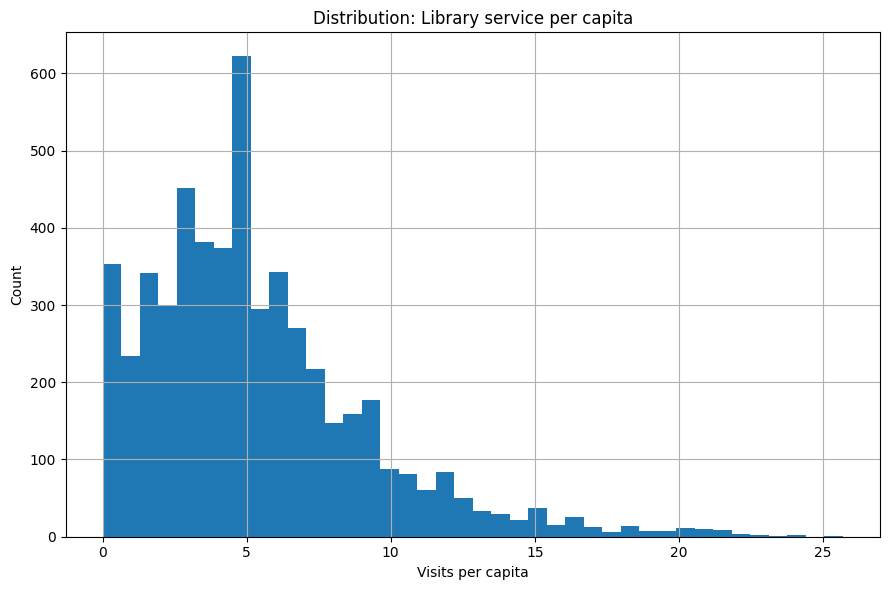

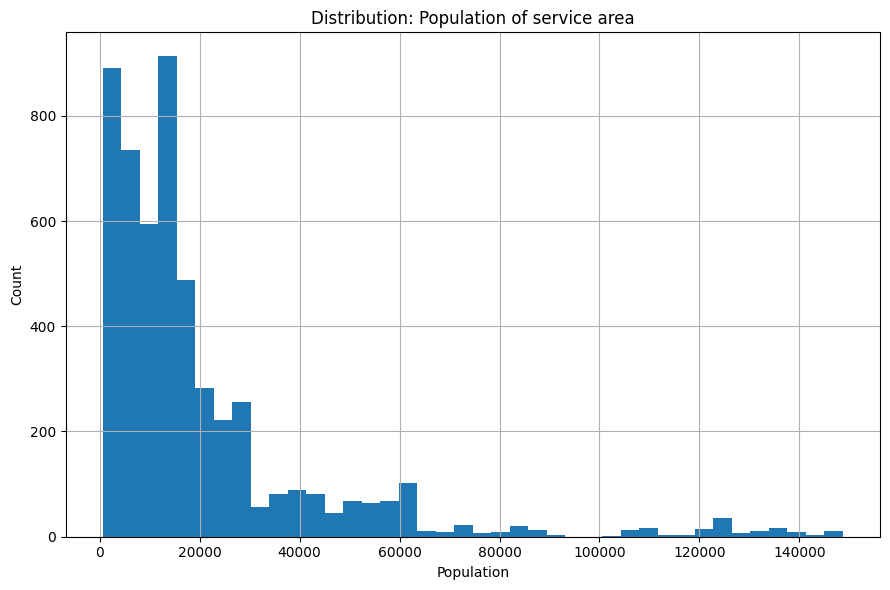

In [65]:
# Histogram of visits_per_capita

if "visits_per_capita" in df.columns:
    plt.figure(figsize=(9, 6))
    df["visits_per_capita"].dropna().hist(bins=40)
    plt.title("Distribution: Library service per capita")
    plt.xlabel("Visits per capita")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "visits_per_capita_hist.png")
    plt.show()

# Histogram of population_of_service_area

if "population_of_service_area" in df.columns:
    plt.figure(figsize=(9, 6))
    df["population_of_service_area"].dropna().hist(bins=40)
    plt.title("Distribution: Population of service area")
    plt.xlabel("Population")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "population_hist.png")
    plt.show()

In [67]:
# Top libraries by visits and visits by capita

if "total_library_visits" in df.columns:
    top_total = df.nlargest(10, "total_library_visits")[["library",
                                                         "county",
                                                         "total_library_visits"]]
    print("\nTop 10 libraries by total visits:")
    print(top_total)

if "visits_per_capita" in df.columns:
    top_percap = df.nlargest(10, "visits_per_capita"), [["library",
                                                        "county",
                                                        "visits_per_capita"]]
    print("\nTop libraries by visits per capita:")
    print(top_percap)


Top 10 libraries by total visits:
                  library     county  total_library_visits
2324  Stamford - Ferguson  Fairfield              989139.0
2142  Stamford - Ferguson  Fairfield              975449.0
1597  Stamford - Ferguson  Fairfield              964578.0
2505  Stamford - Ferguson  Fairfield              961580.0
1779  Stamford - Ferguson  Fairfield              950261.0
1414  Stamford - Ferguson  Fairfield              948556.0
2252             Hartford   Hartford              926303.0
1962  Stamford - Ferguson  Fairfield              916112.0
2688  Stamford - Ferguson  Fairfield              892495.0
2982             Hartford   Hartford              865556.0

Top libraries by visits per capita:
(      fiscal_year                library      county  aenglc_rank  \
2641         2010             New Canaan   Fairfield          2.0   
2459         2009             New Canaan   Fairfield          2.0   
2277         2008             New Canaan   Fairfield          2.0   
11

## Relationship plots

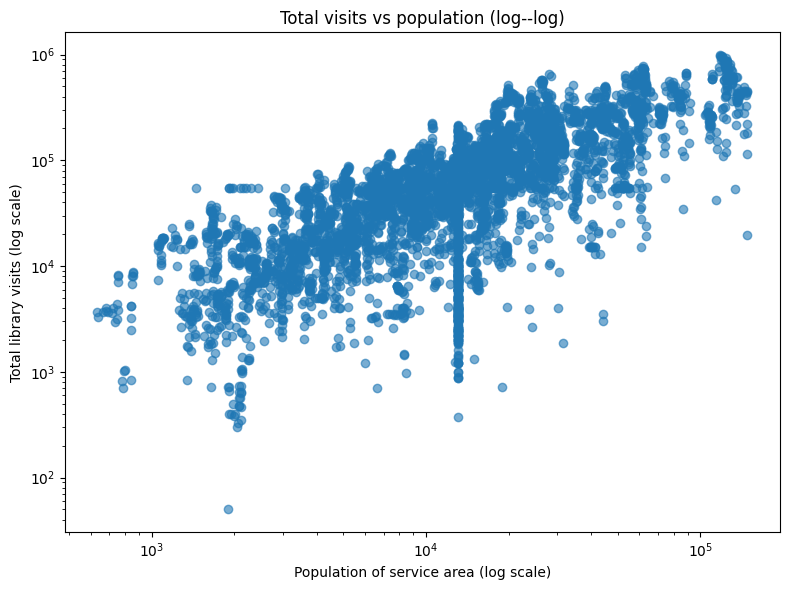

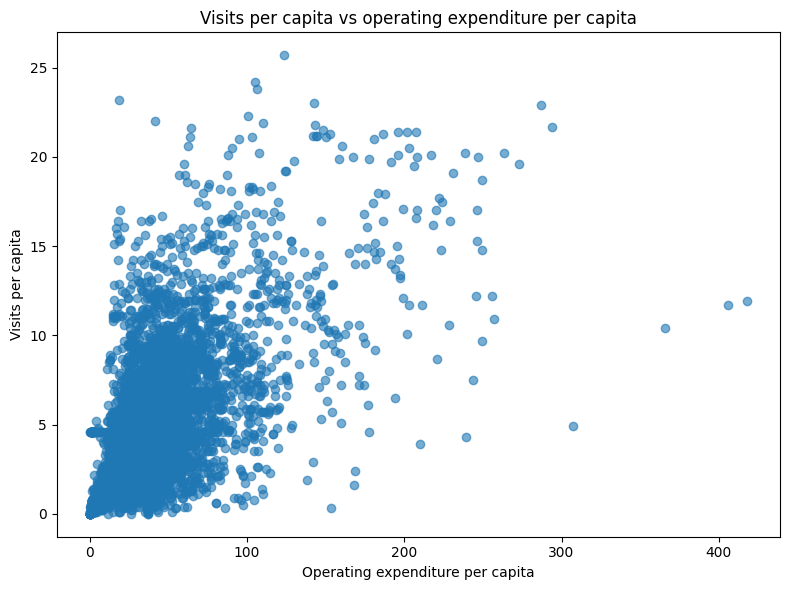

In [69]:
# Scatter:total visits vs population

if "total_library_visits" in df.columns and "population_of_service_area" in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df["population_of_service_area"], df["total_library_visits"], alpha=0.6)
    plt.xscale("log")  # population & visits often skewed, log scale helps
    plt.yscale("log")
    plt.xlabel("Population of service area (log scale)")
    plt.ylabel("Total library visits (log scale)")
    plt.title("Total visits vs population (log--log)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "visits_vs_population_scatter.png")
    plt.show()

# Scatter: visits_per_capita vs operating_expenditures_per_capita (if exists)

if "visits_per_capita" in df.columns and "operating_expenditures_per_capita" in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df["operating_expenditures_per_capita"], df["visits_per_capita"], alpha=0.6)
    plt.xlabel("Operating expenditure per capita")
    plt.ylabel("Visits per capita")
    plt.title("Visits per capita vs operating expenditure per capita")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "visits_vs_expenditures_scatter.png")
    plt.show()

## Trends over time (if fiscal_year present)


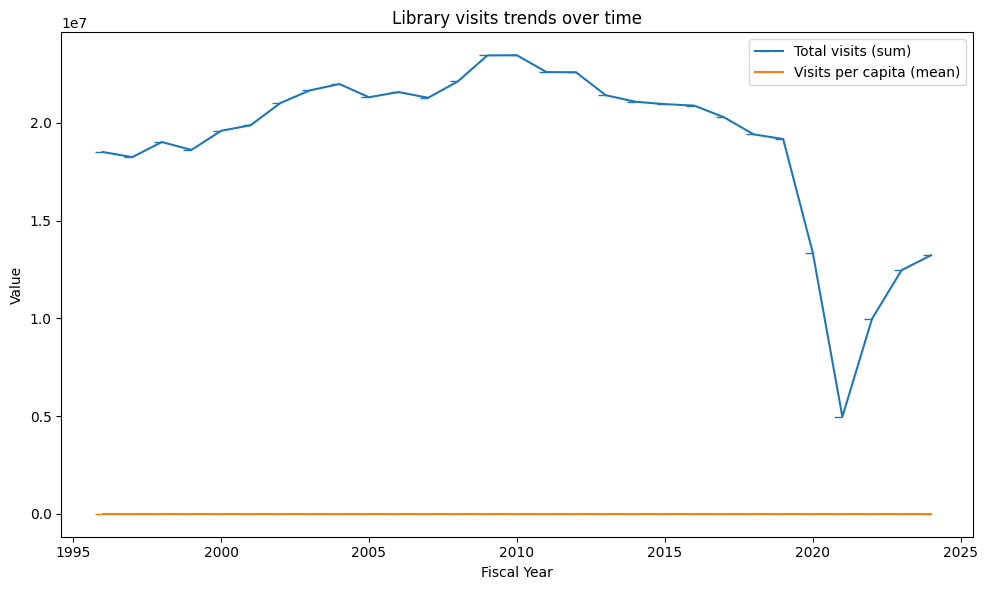

In [73]:
if "fiscal_year"in df.columns:
    # Group by year and compute mean visits per capita and total visits
    yearly = df.groupby("fiscal_year").agg({"total_library_visits": 
                                            "sum" if "total_library_visits" in df.columns
                                            else "mean", "visits_per_capita": "mean"}).reset_index()
    plt.figure(figsize=(10, 6))
    if "total_library_visits" in yearly.columns:
        plt.plot(yearly["fiscal_year"], yearly["total_library_visits"], marker=0, label="Total visits (sum)")
    if "visits_per_capita" in yearly.columns:
        plt.plot(yearly["fiscal_year"], yearly["visits_per_capita"], marker=0, label="Visits per capita (mean)")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Value")
    plt.title("Library visits trends over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "trends_over_time.png")
    plt.show()

## County-level aggration

Top counties by mean visits per capita (top 10)
            libraries_count  mean_visits_percap  total_visits
county                                                       
Fairfield               762            7.192769   177595229.0
Litchfield              744            6.623387    28085923.0
Middlesex               481            6.286486    31800014.0
Hartford                916            5.895991   150770512.0
Tolland                 376            4.652926    19013802.0
New London              599            4.400835    38228832.0
New Haven               839            4.187713    96343372.0
Windham                 561            2.480214    12316962.0


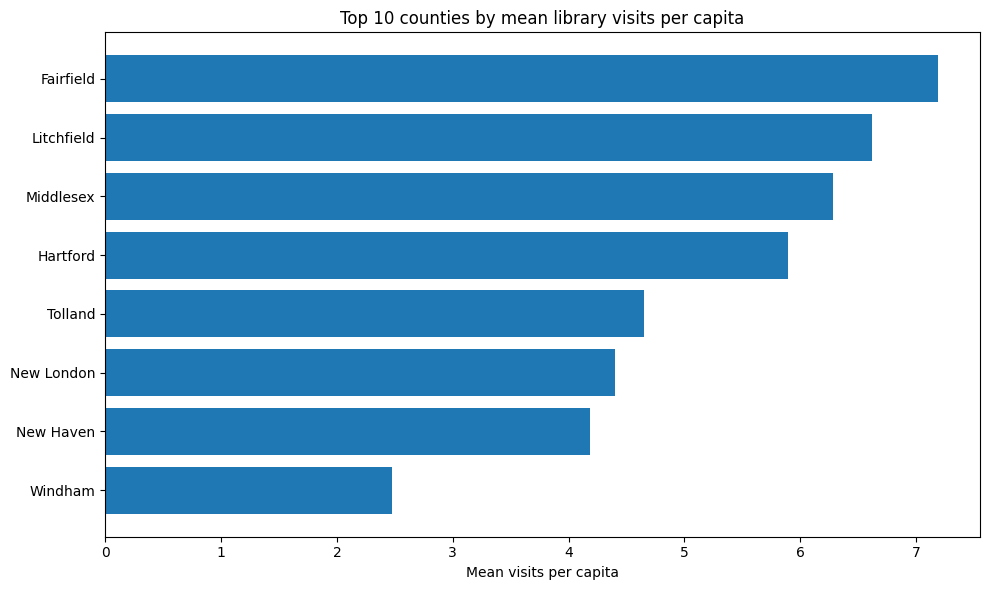

In [75]:
# Find counties with highest visits per capita (average across libraries)

if "county" in df.columns and "visits_per_capita" in df.columns:
    county = df.groupby("county").agg(
        libraries_count = ("library", "count"),
        mean_visits_percap = ("visits_per_capita", "mean"),
        total_visits = ("total_library_visits", "sum")
    if "total_library_visits" in df.columns
    else ("visits_per_capita", "sum")).sort_values("mean_visits_percap", ascending=False)
    print("Top counties by mean visits per capita (top 10)")
    print(county.head(10))

    # Bar plot of top 10 counties

    top_counties = county.head(10).reset_index()
    plt.figure(figsize=(10, 6))
    plt.barh(top_counties["county"][::-1], top_counties["mean_visits_percap"][::-1])
    plt.xlabel("Mean visits per capita")
    plt.title("Top 10 counties by mean library visits per capita")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "top_counties_visits_percap.png")
    plt.show()

## Save cleaned dataset

In [76]:
# Save cleaned CSV for reuse


df.to_csv(CLEANED_PATH, index=False)
print("Cleaned data saved to", CLEANED_PATH)

Cleaned data saved to Public_Libraries_Cleaned.csv
